### NOTE: This notebook is a work in progress! Most of the plots need to be verified, fixed, and/or analyzed further

## Preamble

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Circle, Wedge
import seaborn as sns
from matplotlib.animation import FuncAnimation

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from field_map_g4bl import readFieldMapData
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)
from functions.set_plot_settings import setPlotSettings
setPlotSettings(font=True)

In [2]:
# Read data from actual fieldmap:
data_act = readFieldMapData('hfofo-lattice/fieldmap2.txt')

# Read data from analytic approximation:
data_ana = readFieldMapData('analytic/fieldmap_dipole_solenoids2.txt')

In [2]:
# Length of solenoid (mm):
L = 300

# Distance between solenoid centers (mm):
d = 700

# Function to plot solenoids along z:
def plot_lattice(ax):
    for i in range(6):
        ax.axvspan(xmin=-L/2+d*i, xmax=L/2+d*i, color='lightgray', alpha=0.5)
        if np.mod(i,2) == 0:
            ax.text(d*i-30, 0.95, s='$+$')
        else:
            ax.text(d*i-30, 0.95, s='$-$')

## Full HFOFO field

### Actual fieldmap

In [4]:
unique_z_act = np.sort(data_act['z'].unique())
init_data_act = data_act[data_act['z'] == unique_z_act[0]]
x_unique_act = np.sort(init_data_act['x'].unique())
y_unique_act = np.sort(init_data_act['y'].unique())
X_act, Y_act = np.meshgrid(x_unique_act, y_unique_act)
Br_init_act = init_data_act.pivot_table(index='y', columns='x', values='Br').values

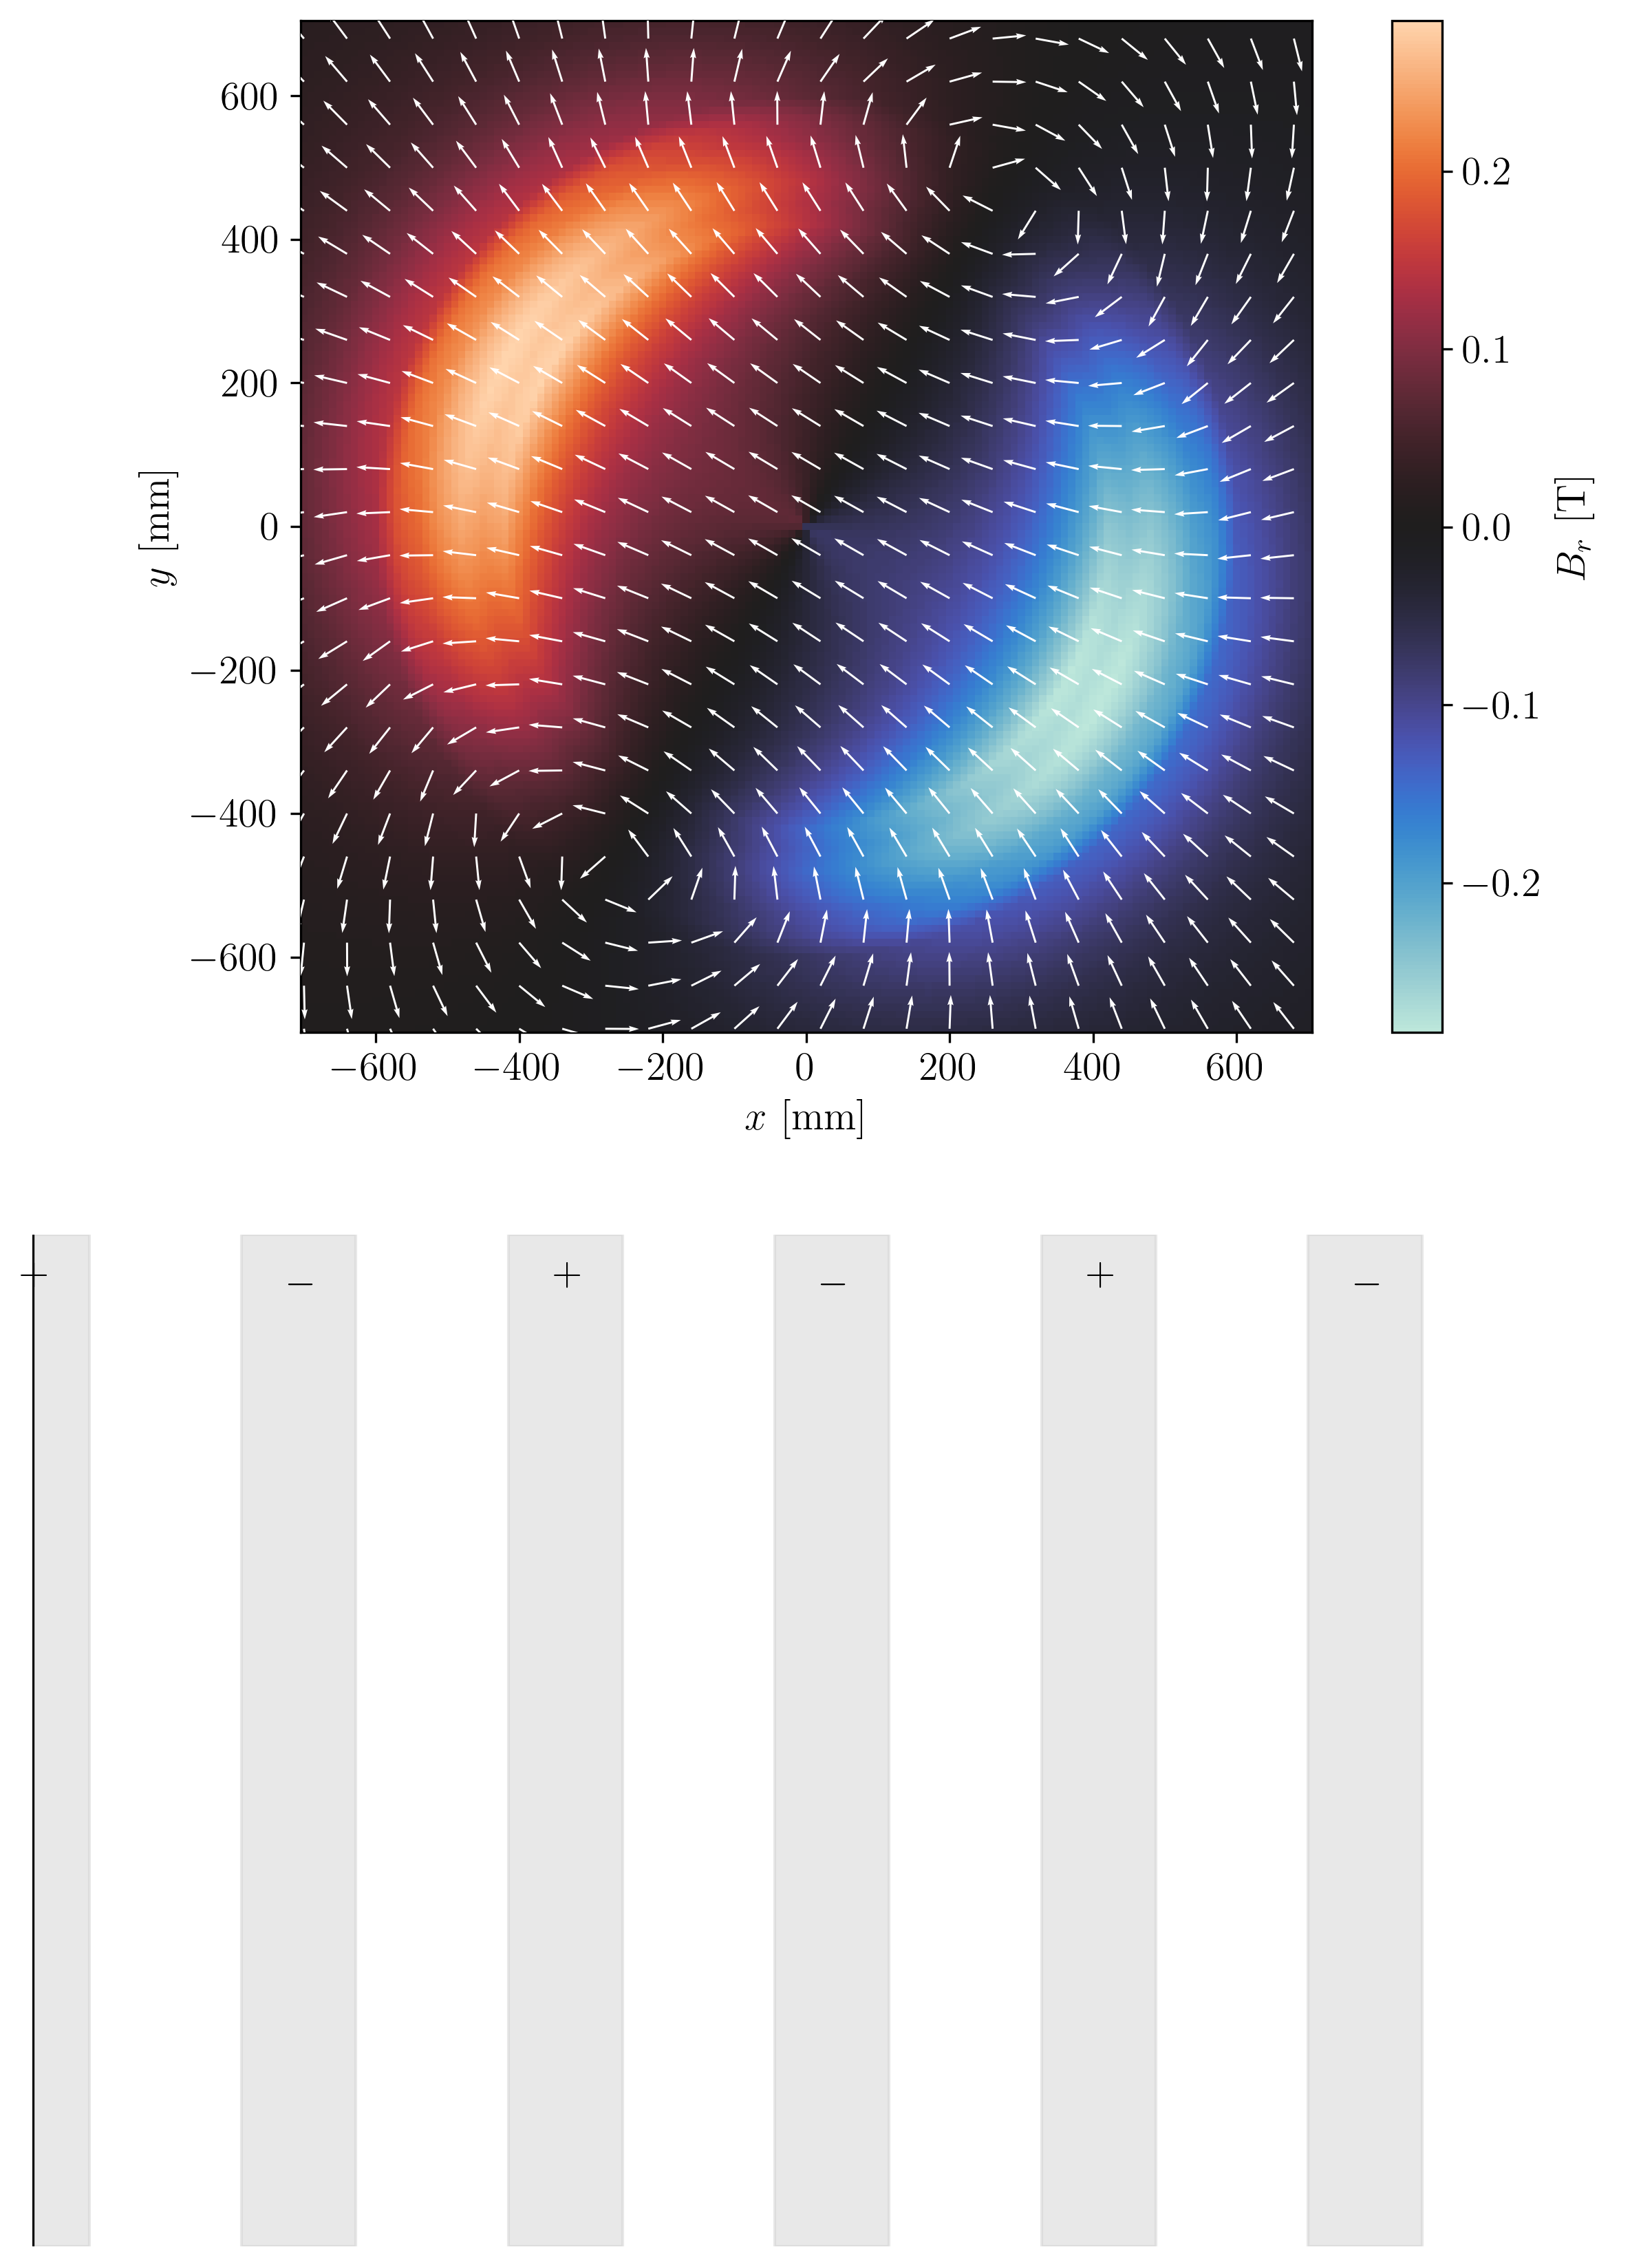

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_act[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_act, Y_act, Br_init_act, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_act[frame]
    vline.set_xdata([z_val])

    data_slice = data_act[data_act['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_act[::step, ::step]
    Y_ds = Y_act[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_act), interval=100, blit=False, repeat=False)
animation.save('test_act.gif', writer='pillow')

### Analytic fieldmap

In [6]:
unique_z_ana = np.sort(data_ana['z'].unique())
init_data_ana = data_ana[data_ana['z'] == unique_z_ana[0]]
x_unique_ana = np.sort(init_data_ana['x'].unique())
y_unique_ana = np.sort(init_data_ana['y'].unique())
X_ana, Y_ana = np.meshgrid(x_unique_ana, y_unique_ana)
Br_init_ana = init_data_ana.pivot_table(index='y', columns='x', values='Br').values

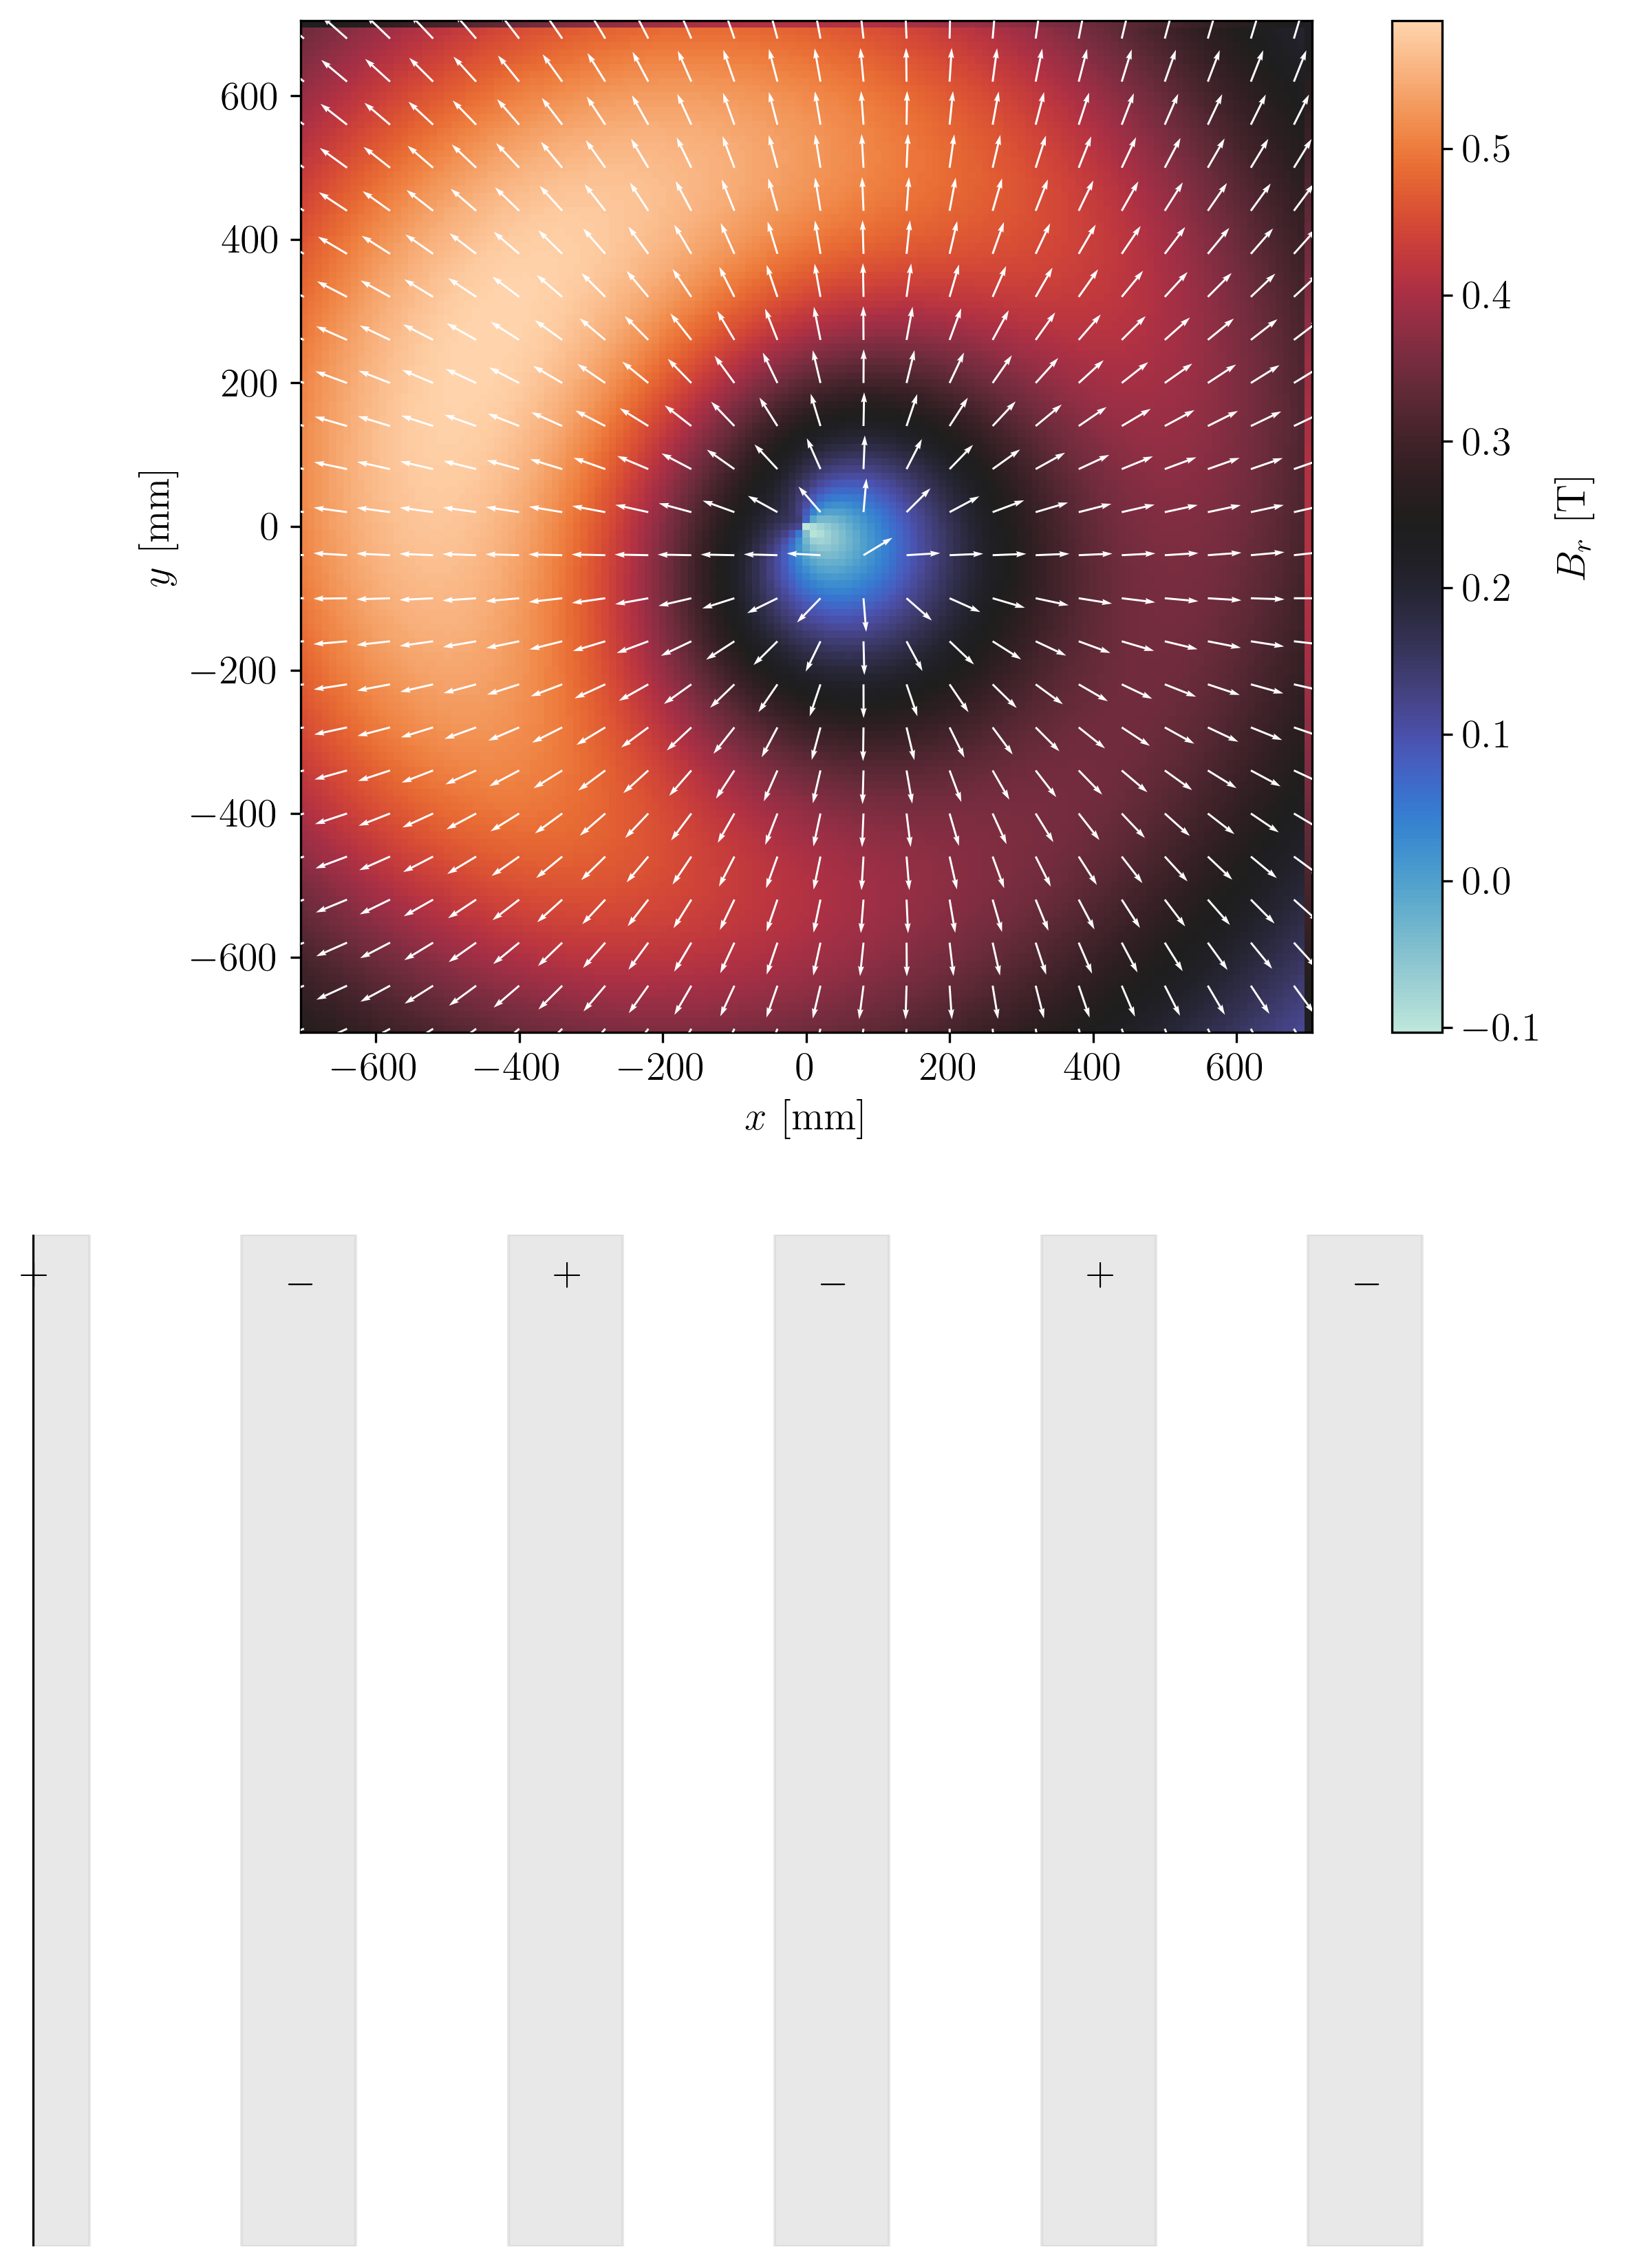

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_ana[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_ana, Y_ana, Br_init_ana, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_ana[frame]
    vline.set_xdata([z_val])

    data_slice = data_ana[data_ana['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_ana[::step, ::step]
    Y_ds = Y_ana[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_ana), interval=100, blit=False, repeat=False)
animation.save('test_ana.gif', writer='pillow')

### Difference

In [8]:
Br_init_diff = Br_init_act - Br_init_ana

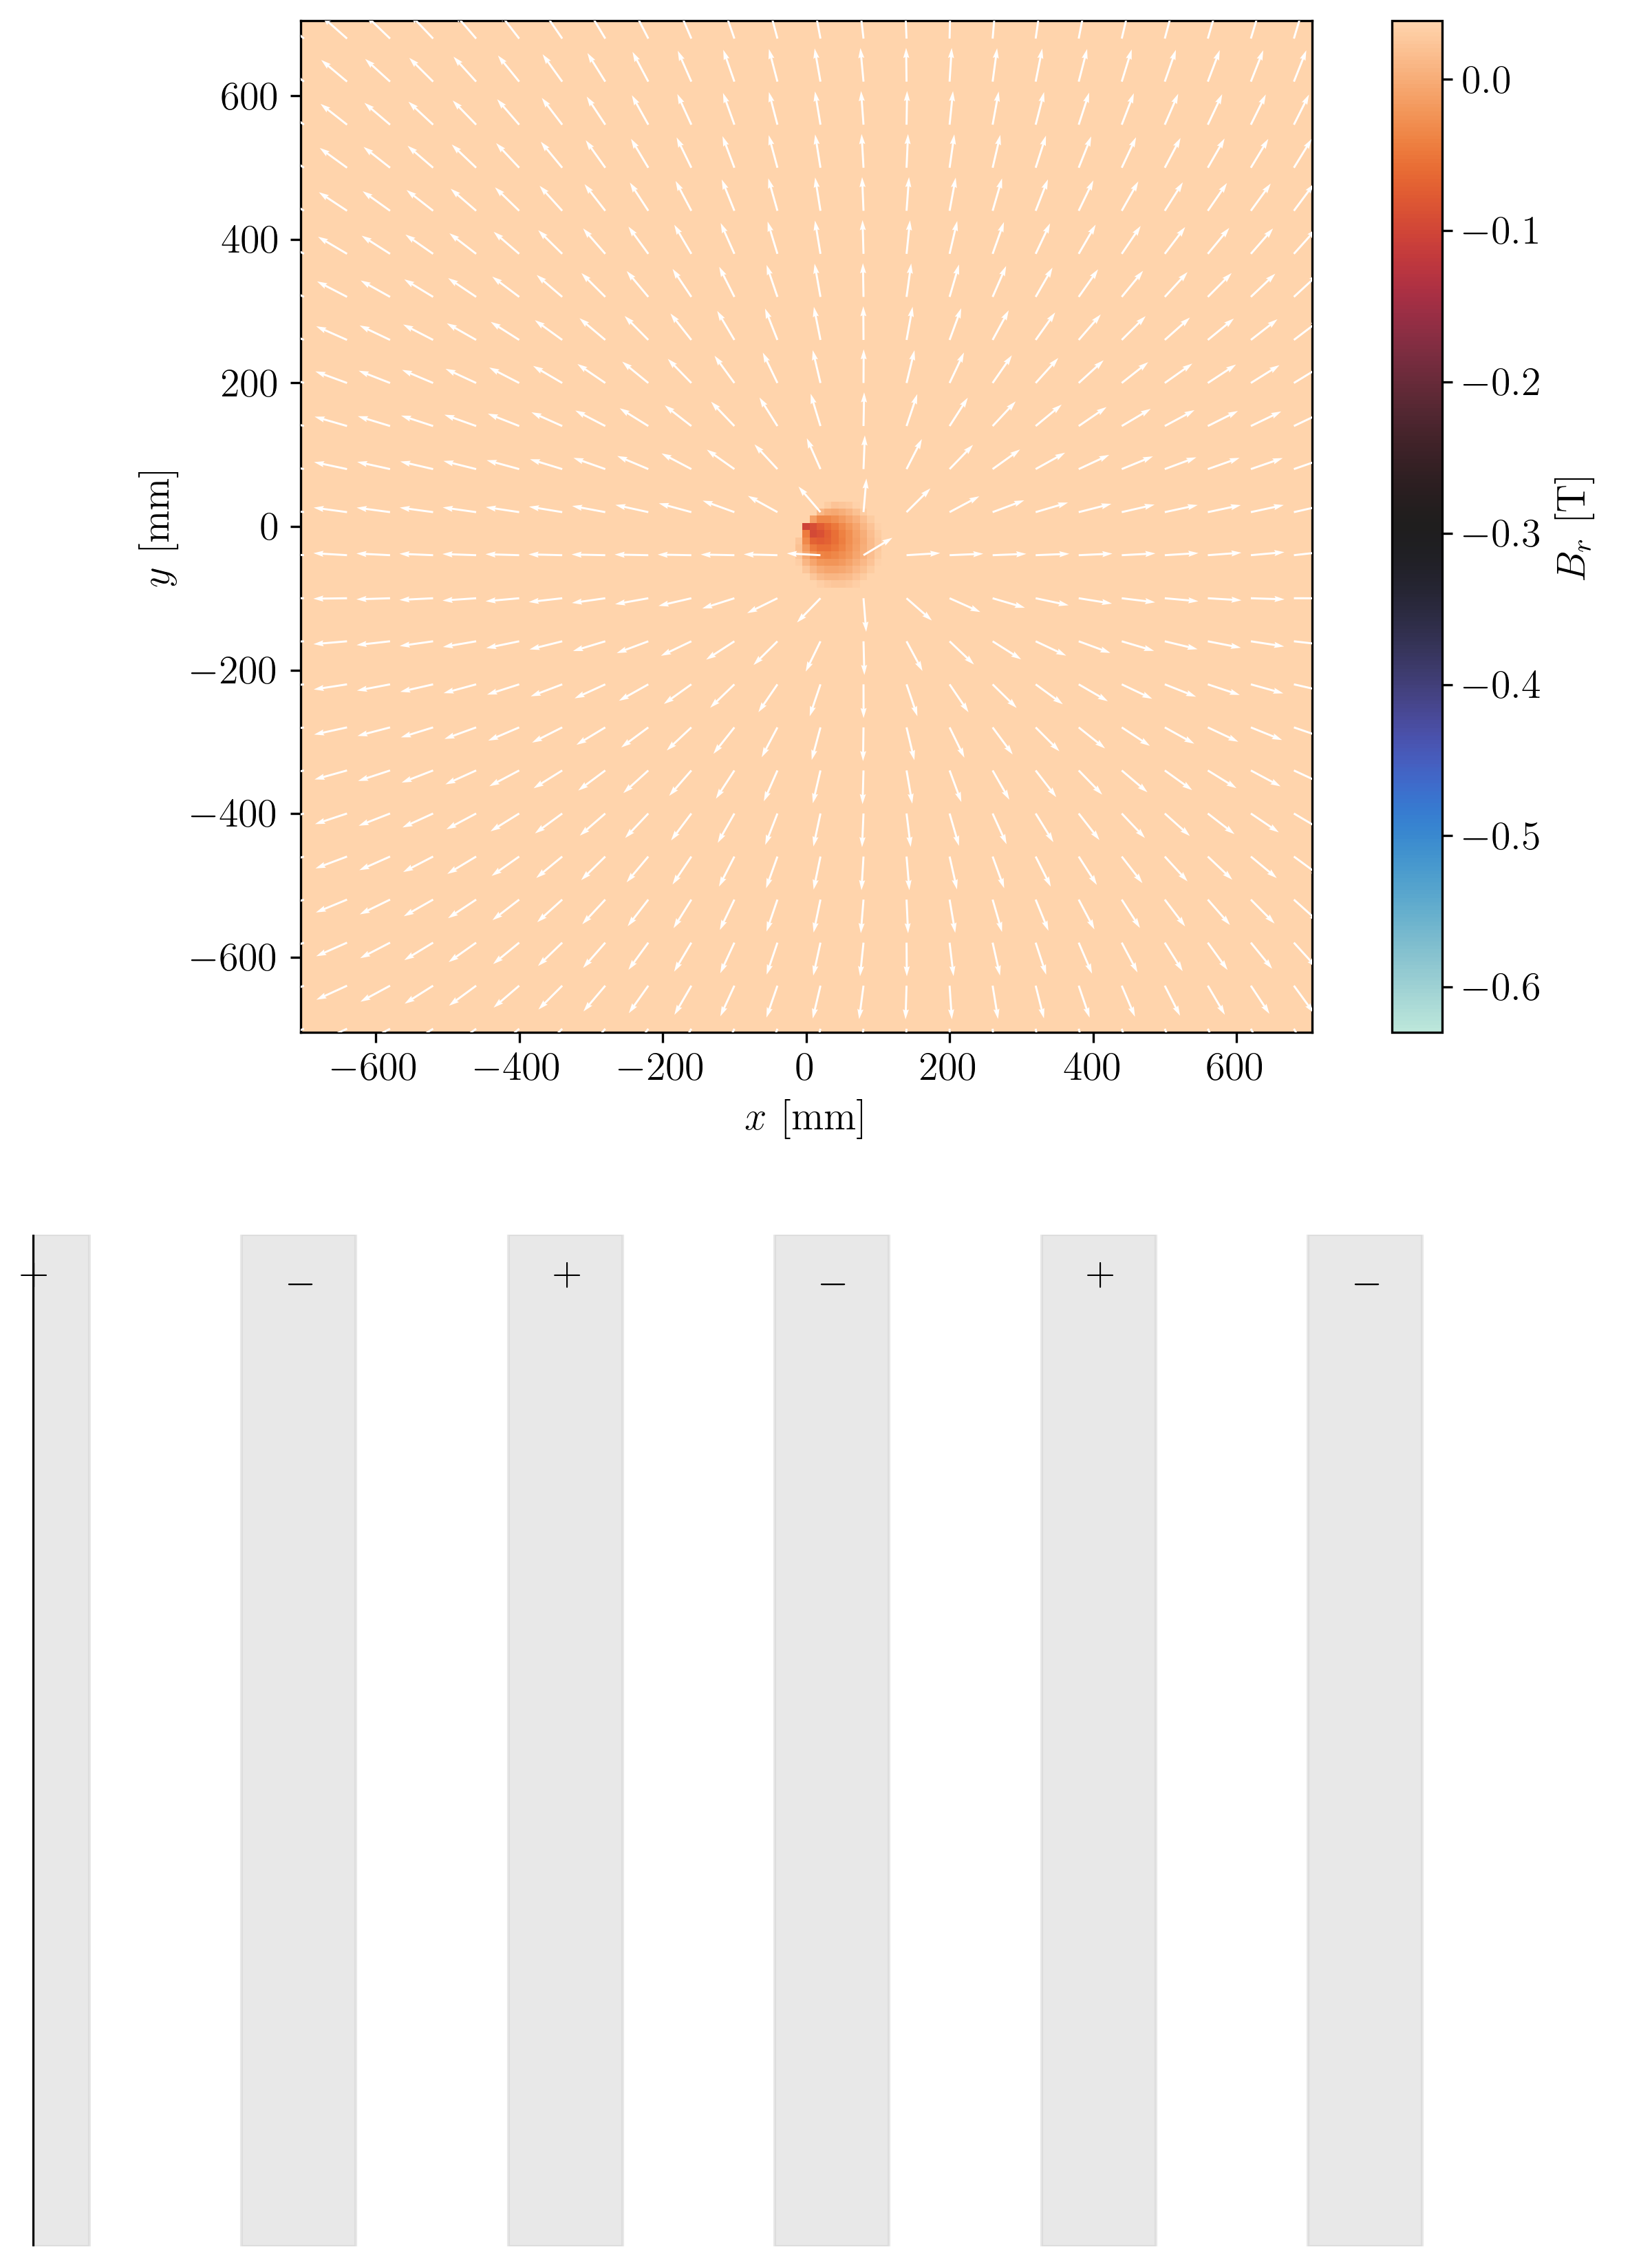

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_ana[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_ana, Y_ana, Br_init_diff, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_ana[frame]
    vline.set_xdata([z_val])

    data_slice = data_ana[data_ana['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_ana[::step, ::step]
    Y_ds = Y_ana[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_ana), interval=100, blit=False, repeat=False)
animation.save('test_diff.gif', writer='pillow')

## Residual field

In [4]:
# Read data from actual residual fieldmap:
data_hfofo = readFieldMapData('hfofo-lattice/fieldmap_hfofo.txt')
data_fofo = readFieldMapData('hfofo-lattice/fieldmap_fofo.txt')
data_act = data_hfofo.copy()
data_act['Bx'] = data_hfofo['Bx'] - data_fofo['Bx']
data_act['By'] = data_hfofo['By'] - data_fofo['By']
data_act['Bz'] = data_hfofo['Bz'] - data_fofo['Bz']
data_act['Br'] = np.sqrt(data_act['Bx']**2 + data_act['By']**2)

# Read data from analytic approximation:
# data_ana = readFieldMapData('analytic/fieldmap_dipole2.txt')
data_ana = readFieldMapData('analytic/fieldmap_dipole_test.txt')

### Actual fieldmap

In [5]:
unique_z_act = np.sort(data_act['z'].unique())
init_data_act = data_act[data_act['z'] == unique_z_act[0]]
x_unique_act = np.sort(init_data_act['x'].unique())
y_unique_act = np.sort(init_data_act['y'].unique())
X_act, Y_act = np.meshgrid(x_unique_act, y_unique_act)
Br_init_act = init_data_act.pivot_table(index='y', columns='x', values='Br').values

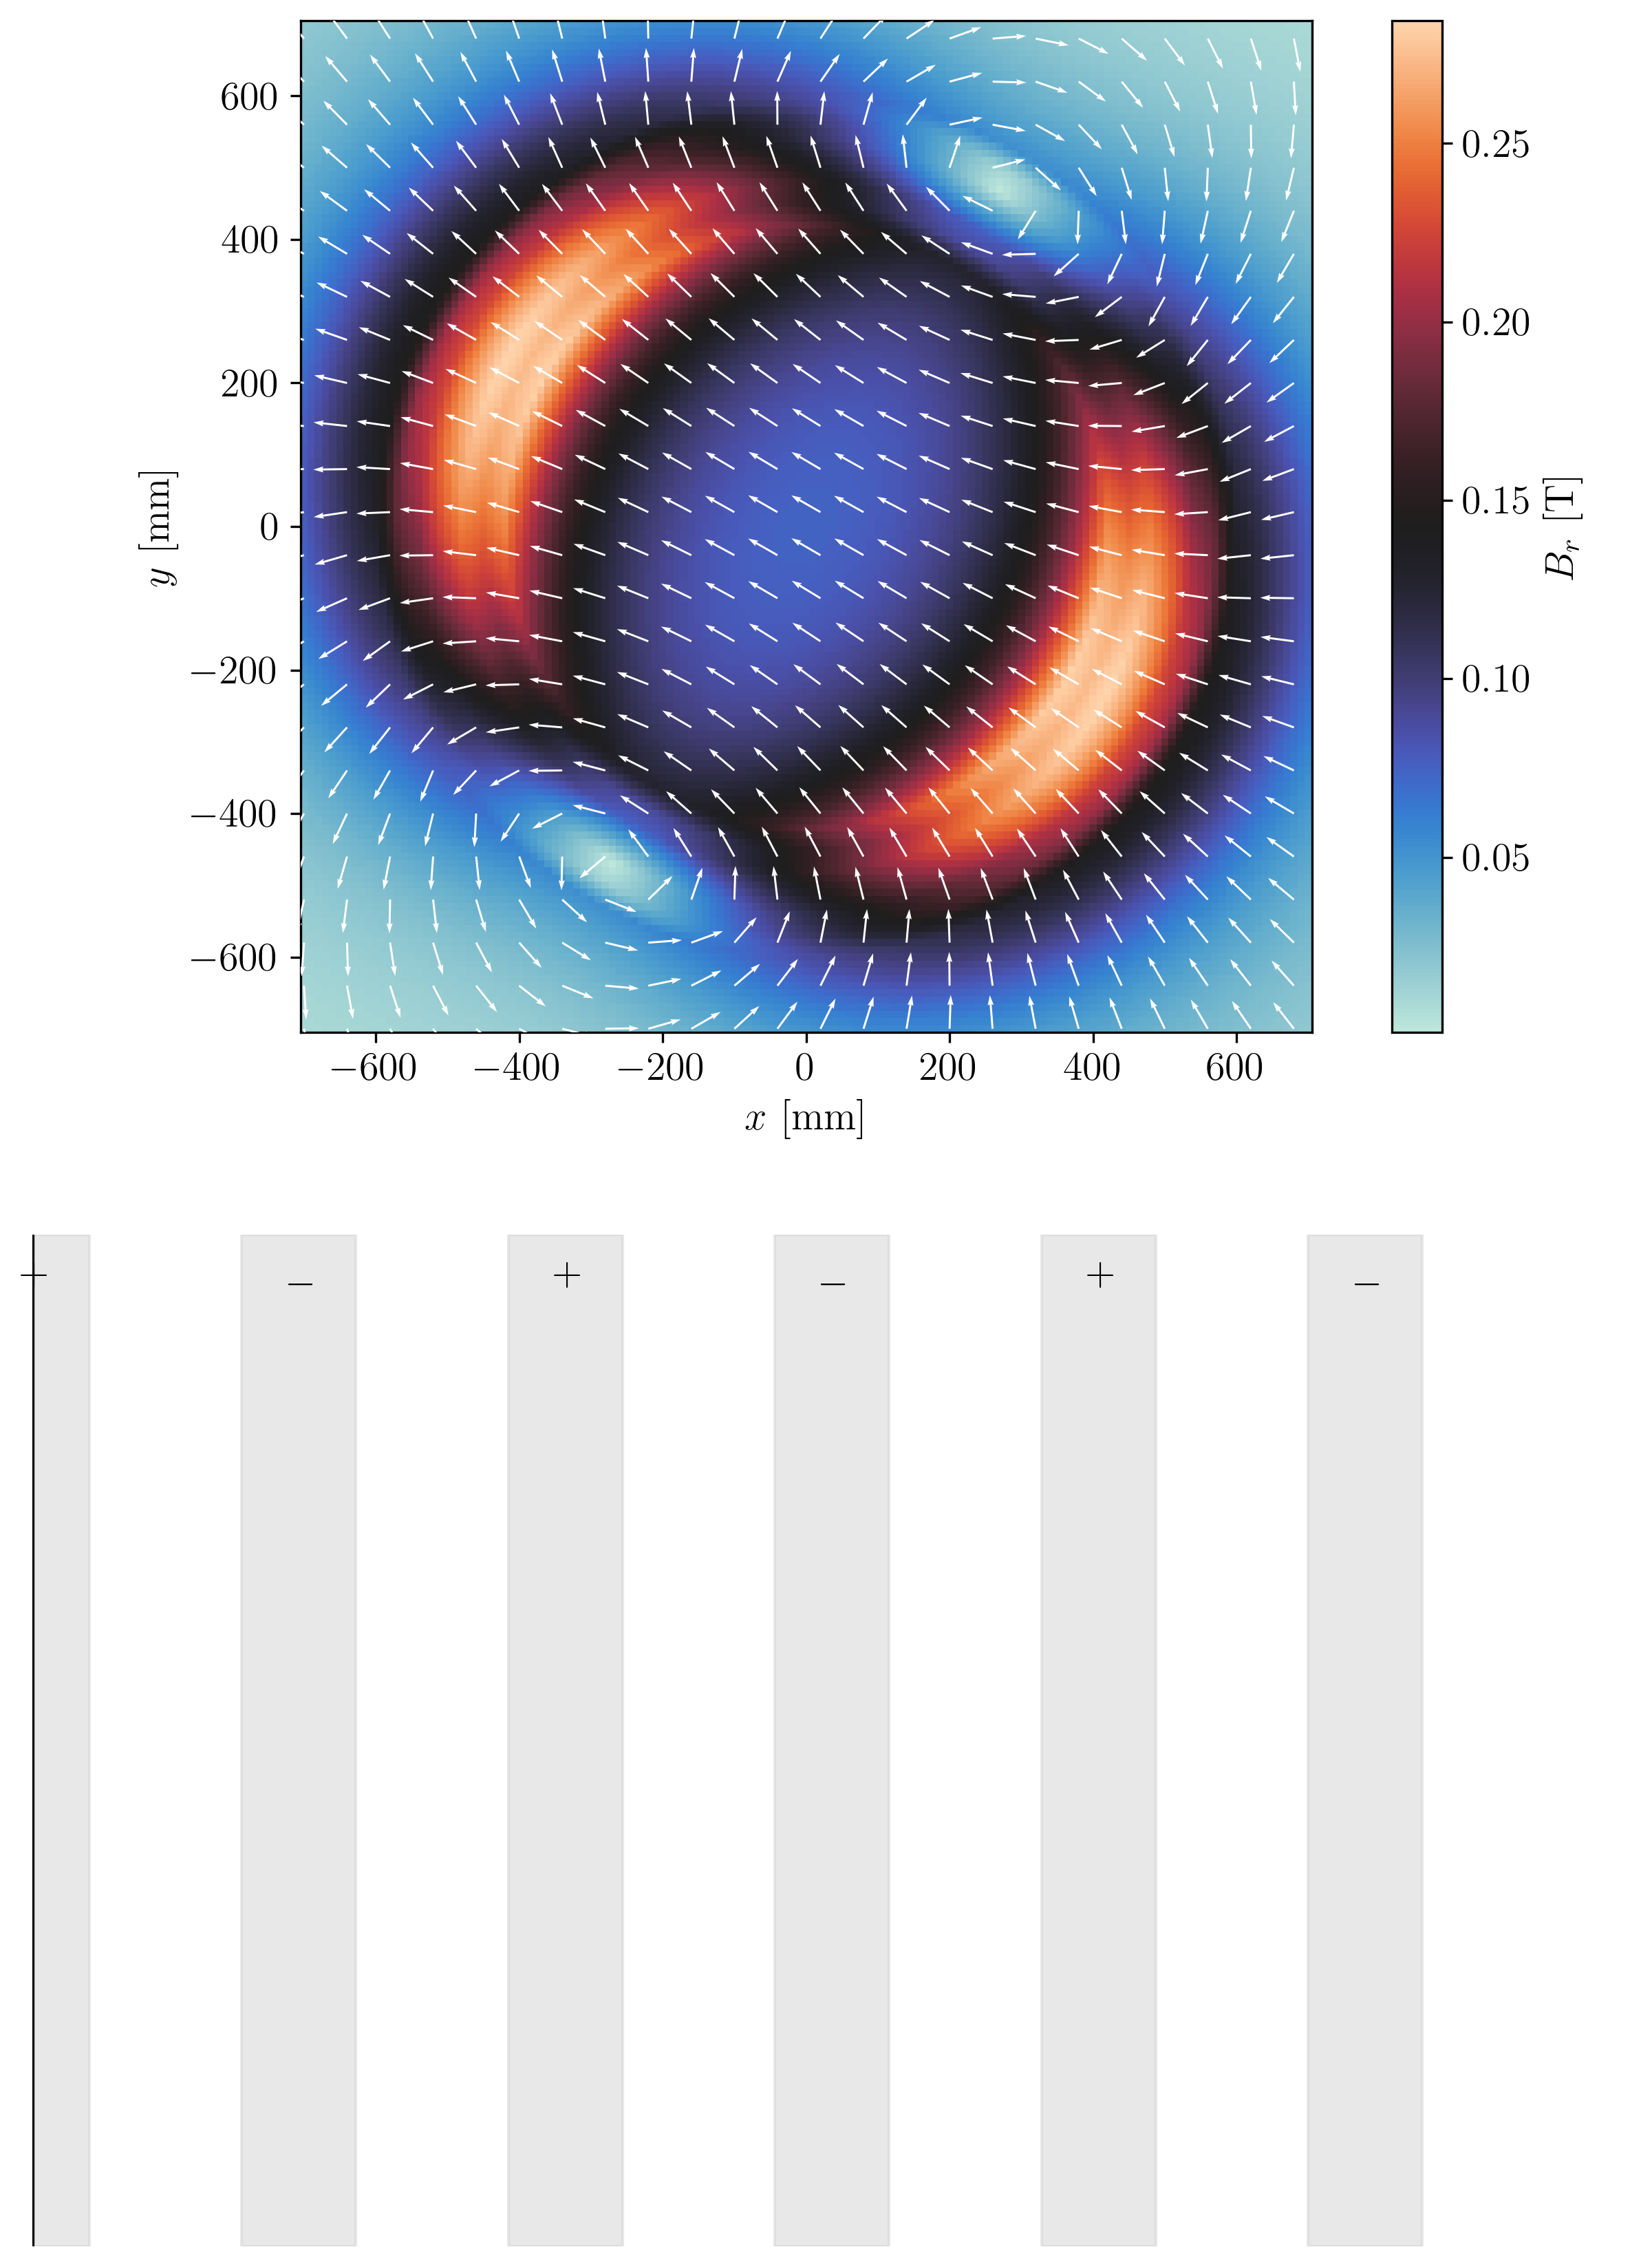

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_act[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_act, Y_act, Br_init_act, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_act[frame]
    vline.set_xdata([z_val])

    data_slice = data_act[data_act['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_act[::step, ::step]
    Y_ds = Y_act[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_act), interval=100, blit=False, repeat=False)
animation.save('test_act_res.gif', writer='pillow')

### Analytic fieldmap

In [7]:
unique_z_ana = np.sort(data_ana['z'].unique())
init_data_ana = data_ana[data_ana['z'] == unique_z_ana[0]]
x_unique_ana = np.sort(init_data_ana['x'].unique())
y_unique_ana = np.sort(init_data_ana['y'].unique())
X_ana, Y_ana = np.meshgrid(x_unique_ana, y_unique_ana)
Br_init_ana = init_data_ana.pivot_table(index='y', columns='x', values='Br').values

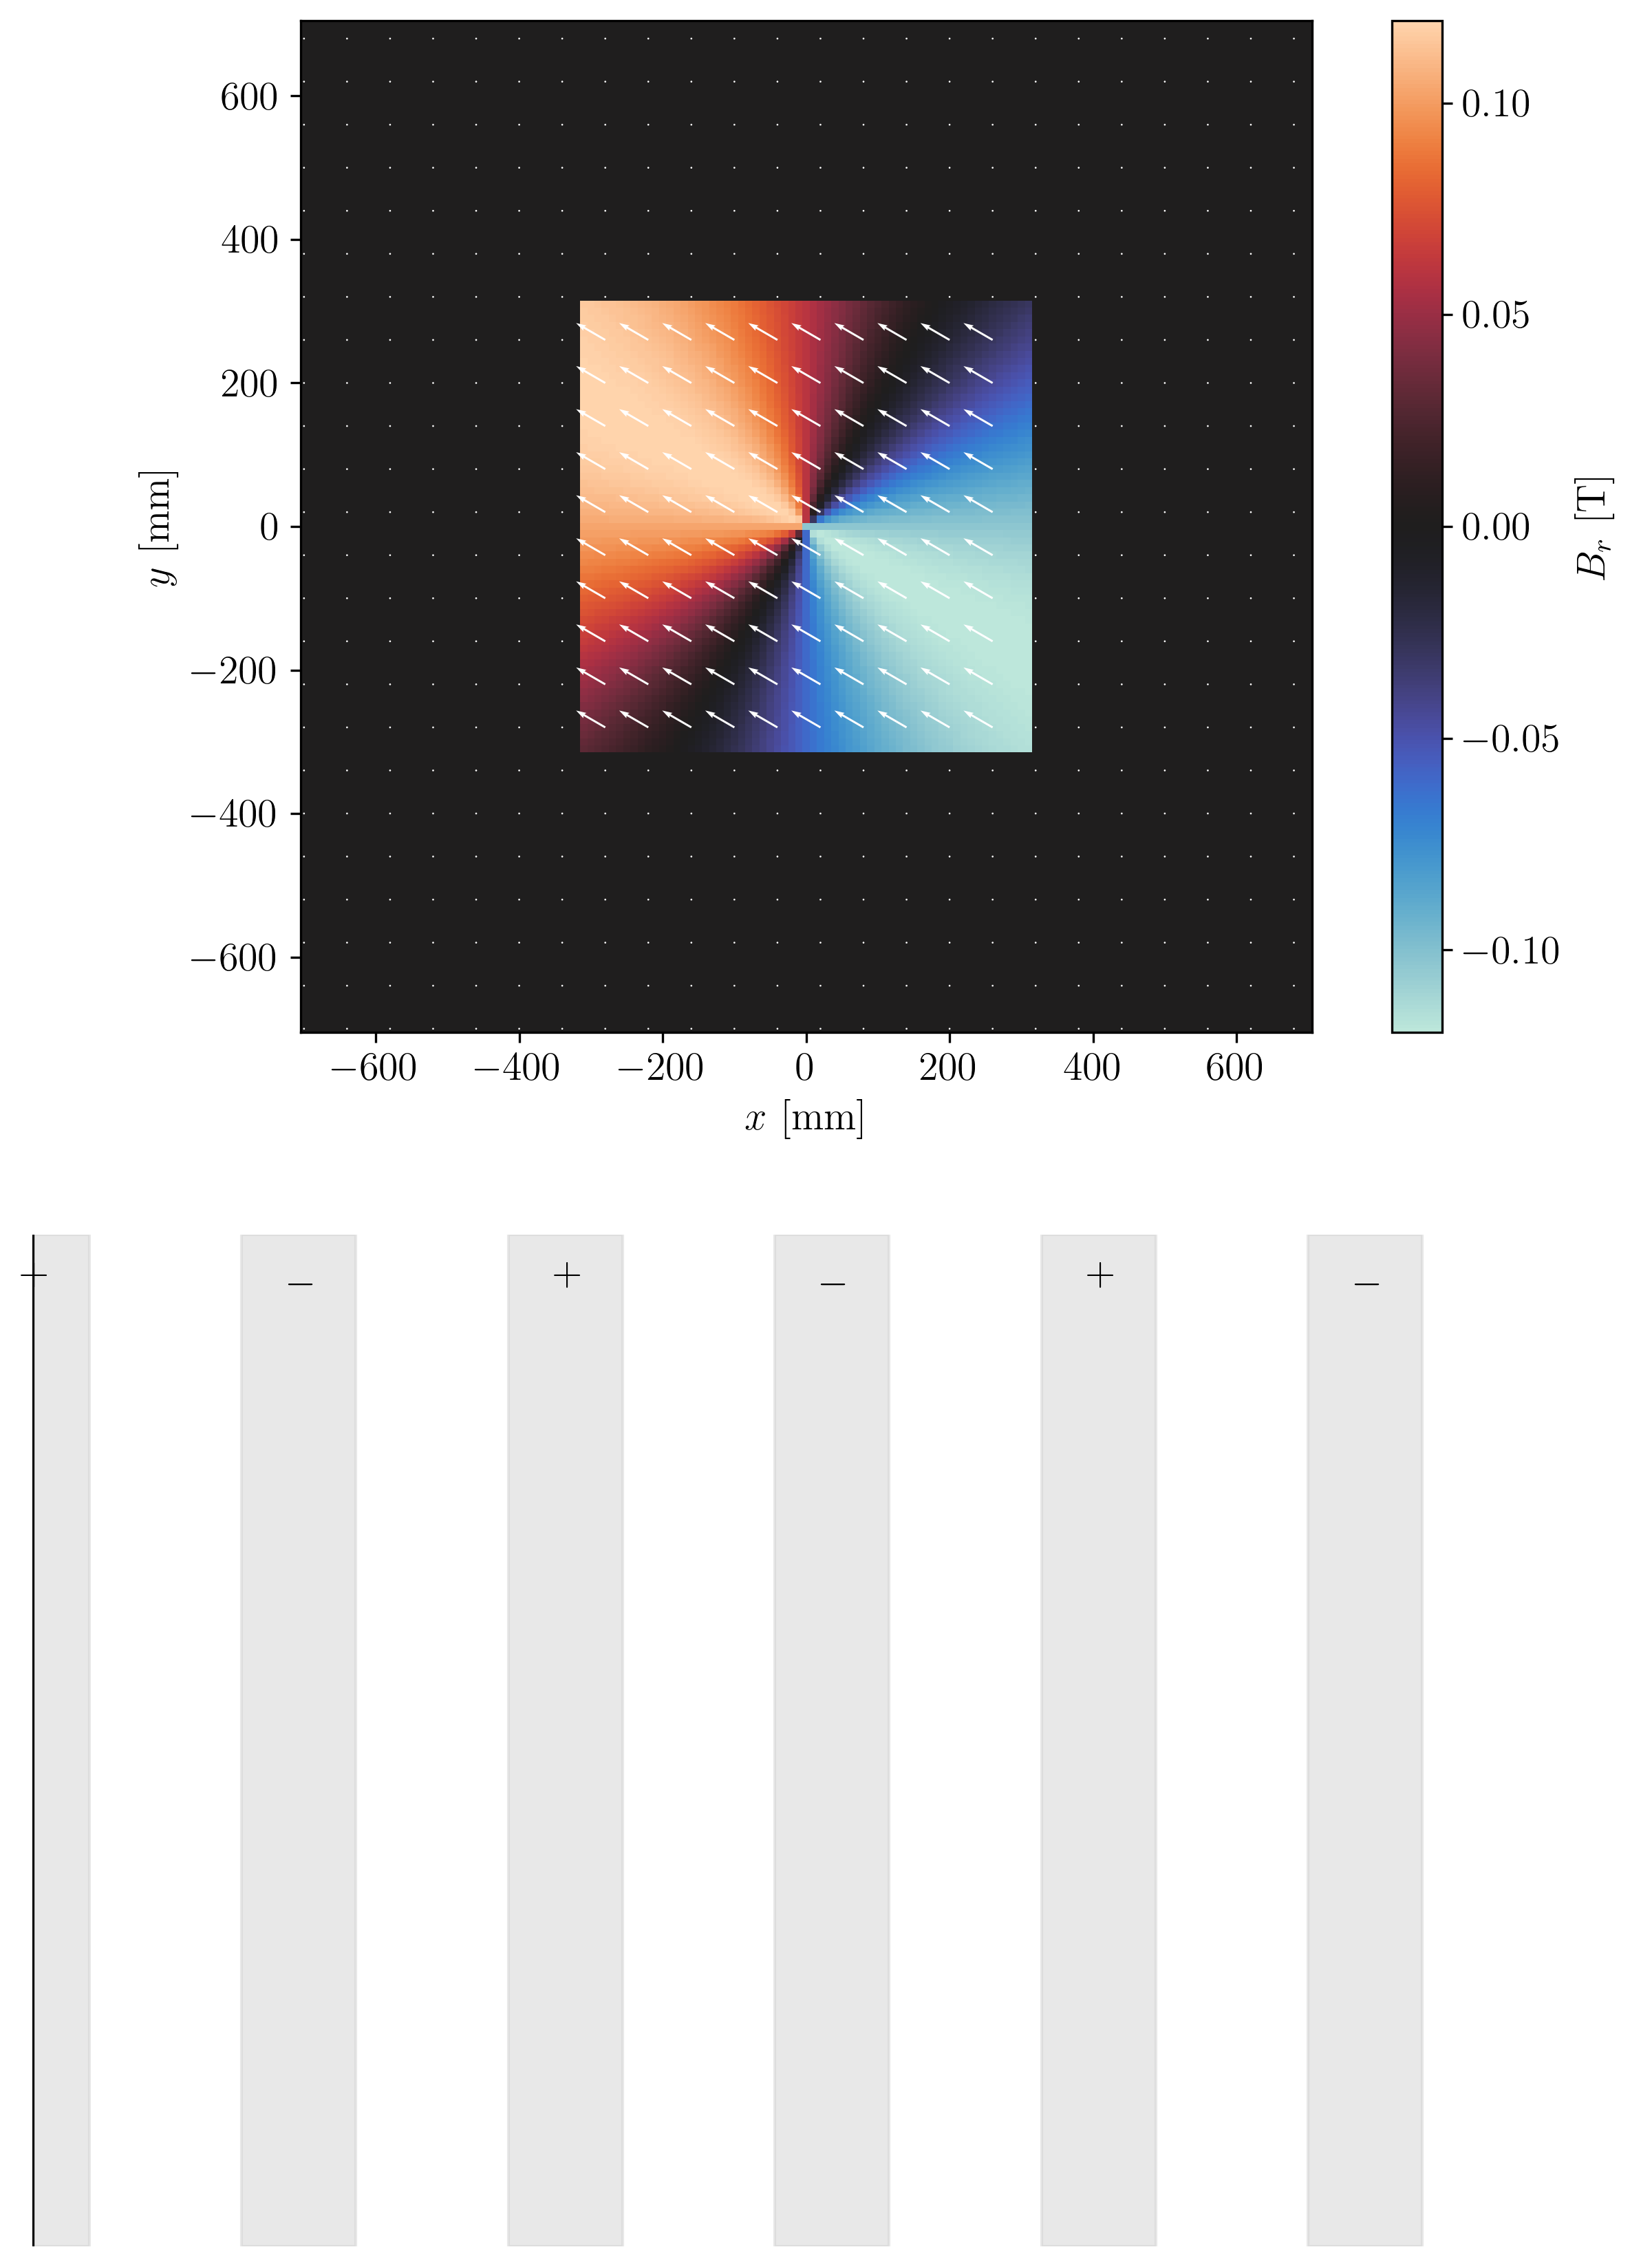

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_ana[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_ana, Y_ana, Br_init_ana, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_ana[frame]
    vline.set_xdata([z_val])

    data_slice = data_ana[data_ana['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_ana[::step, ::step]
    Y_ds = Y_ana[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_ana), interval=100, blit=False, repeat=False)
animation.save('test_ana_res.gif', writer='pillow')

### Difference

In [15]:
Br_init_diff = Br_init_act - Br_init_ana

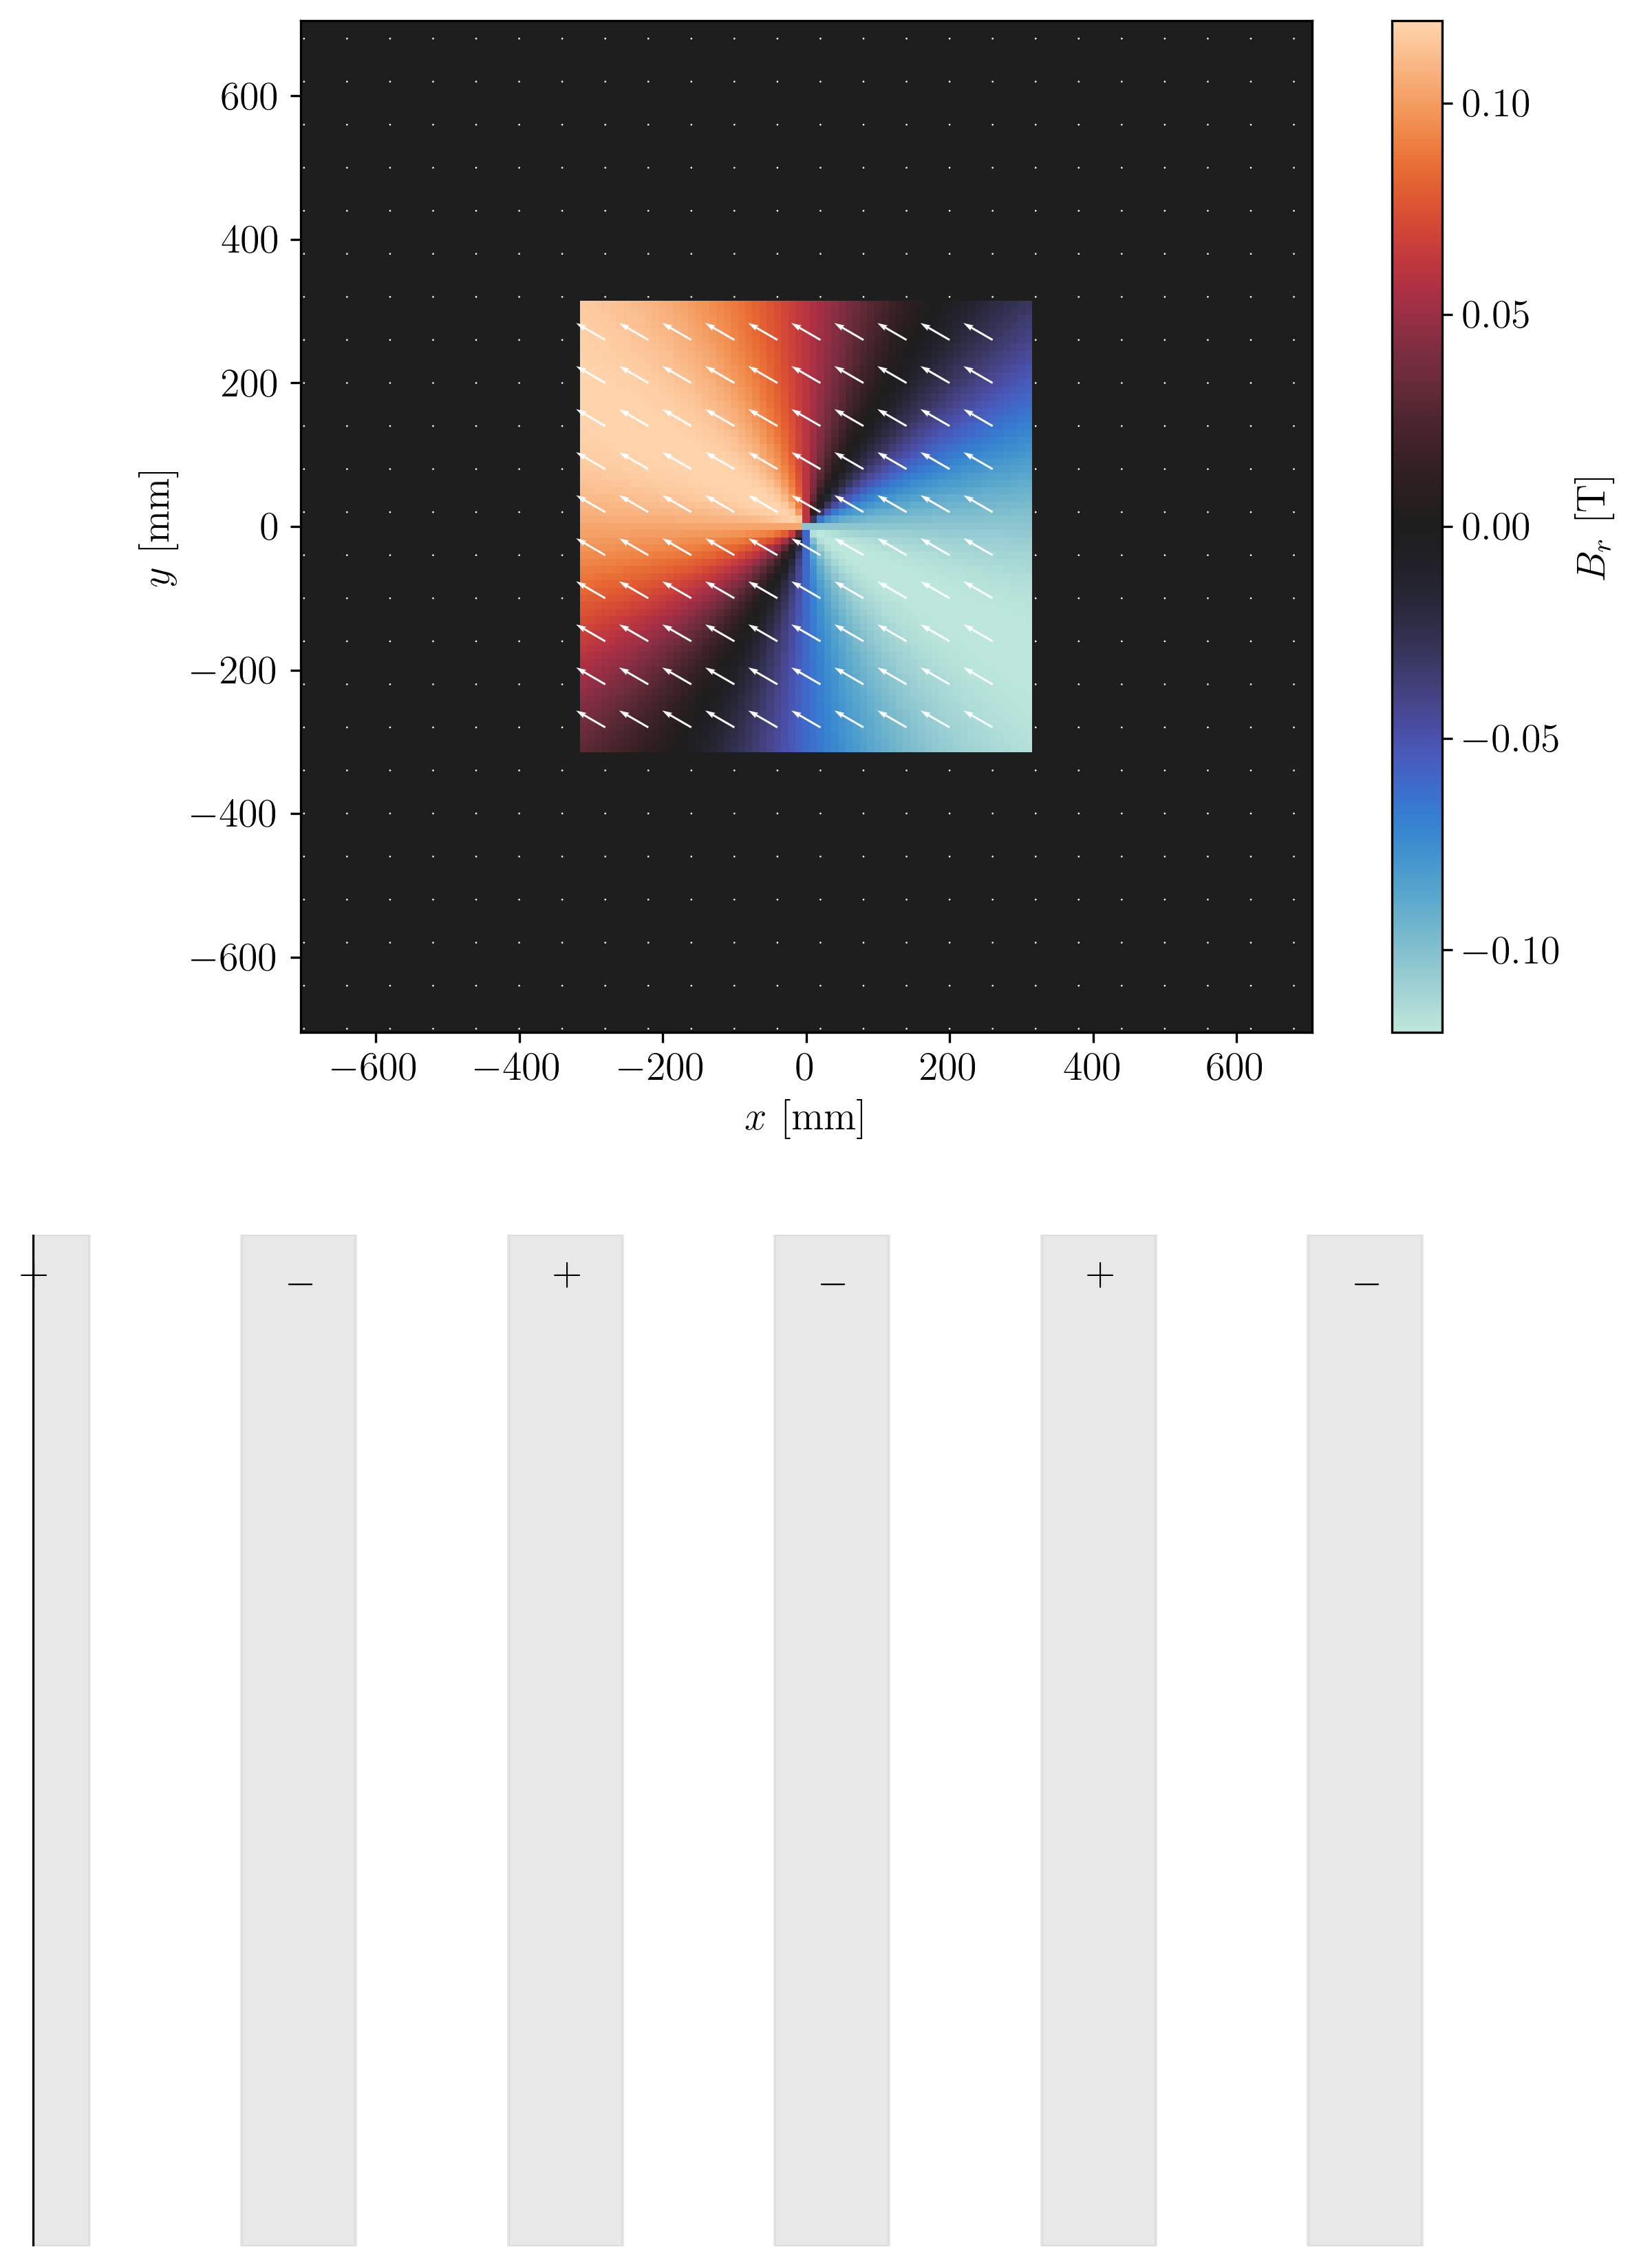

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(10,14))
ax, ax2 = axs[0], axs[1]

arrayy = [0, 0]
ax2.set_xlim(0, 4200)
plot_lattice(ax2)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_frame_on(False)
vline = ax2.axvline(x=unique_z_ana[0], color='black')

ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
ax.set_aspect('equal')

cmap = sns.color_palette("icefire", as_cmap=True)
pcm = ax.pcolormesh(X_ana, Y_ana, Br_init_diff, cmap=cmap)
cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')

quiver_plot = None

step = 6

def animate(frame):
    global quiver_plot

    z_val = unique_z_ana[frame]
    vline.set_xdata([z_val])

    data_slice = data_ana[data_ana['z'] == z_val]

    Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
    By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
    Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

    X_ds = X_ana[::step, ::step]
    Y_ds = Y_ana[::step, ::step]
    Bx_ds = Bx_grid[::step, ::step]
    By_ds = By_grid[::step, ::step]

    magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
    Bx_norm = Bx_ds / (magnitude + 1e-12)
    By_norm = By_ds / (magnitude + 1e-12)

    pcm.set_array(Br_grid.ravel())

    if quiver_plot:
        quiver_plot.remove()

    quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=30, width=0.002, zorder=10)

    return [pcm, vline, quiver_plot]

animation = FuncAnimation(fig, animate, frames=len(unique_z_ana), interval=100, blit=False, repeat=False)
animation.save('test_diff_res.gif', writer='pillow')